# Train MobileNetV2 (GitHub repo) on your dataset

Pick one of these official PyTorch repos and train **the actual MobileNetV2** end‑to‑end on your images:

- **d-li14/mobilenetv2.pytorch** (training script & multiple width multipliers)  
- **tonylins/pytorch-mobilenet-v2** (clean MobileNetV2 module)

**Dataset expected:**
```
model/datasets/
  train/{fresh,not_fresh}/{species}/*.jpg
  validation/{fresh,not_fresh}/{species}/*.jpg
  test/{fresh,not_fresh}/{species}/*.jpg   # optional
```

We flatten `(freshness, species)` into one label like `fresh__bigeye_scad` so we can use the standard ImageNet training code.

## 0) Choose repo (`REPO`): `'dli14'` or `'tonylins'`

In [1]:
# (Removed) Repo selection not needed. We'll use official torchvision MobileNetV2.
REPO = 'torchvision'
print('Using official torchvision MobileNetV2')


Using official torchvision MobileNetV2


## 1) Install PyTorch (skip if already installed)

In [2]:
import sys, subprocess
def pipi(args):
    print('> pip', ' '.join(args))
    subprocess.check_call([sys.executable, '-m', 'pip'] + args)
try:
    import torch, torchvision
    print('Torch/Torchvision already installed')
except Exception as e:
    print('Installing PyTorch CUDA 11.8 wheels...')
    pipi(['install','torch','torchvision','torchaudio','--index-url','https://download.pytorch.org/whl/cu118'])

Torch/Torchvision already installed


## 2) Clone the chosen repo

In [3]:
print('Skip cloning: using torchvision, no external repo required.')


Skip cloning: using torchvision, no external repo required.


## 3) Split datasets (multitask splitter inside notebook)

In [4]:
# split_multitask.py
# Usage (from model/source_code):
#   python split_multitask.py --src ../datasets/_raw --dst ../datasets --train 0.6 --val 0.2 --test 0.2 --clean --move --seed 123
from __future__ import annotations
from pathlib import Path
import argparse, random, shutil, math

ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect(src_root: Path) -> dict[tuple[str, str], list[Path]]:
    buckets: dict[tuple[str,str], list[Path]] = {}
    if not src_root.exists():
        raise SystemExit(f"Source not found: {src_root}")
    for freshness_dir in src_root.iterdir():  # fresh / not_fresh
        if not freshness_dir.is_dir(): 
            continue
        f_name = freshness_dir.name
        for species_dir in freshness_dir.iterdir():  # species
            if not species_dir.is_dir():
                continue
            s_name = species_dir.name
            key = (f_name, s_name)
            buckets.setdefault(key, [])
            for p in species_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in ALLOWED:
                    buckets[key].append(p)
    return buckets

def split_counts(n: int, r_train: float, r_val: float, r_test: float) -> tuple[int,int,int]:
    if not (0.999 <= (r_train + r_val + r_test) <= 1.001):
        raise ValueError("Splits must sum to 1.0")
    base = [math.floor(n * r) for r in (r_train, r_val, r_test)]
    rem = n - sum(base)
    # distribute remaining items by largest fractional parts
    fracs = [n * r - b for r, b in zip((r_train, r_val, r_test), base)]
    order = sorted(range(3), key=lambda i: fracs[i], reverse=True)
    for i in order[:rem]:
        base[i] += 1
    return tuple(base)

def _clear_dir(d: Path):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

def place(files: list[Path], dst_root: Path, subset: str, f_name: str, s_name: str, move: bool):
    out_dir = dst_root / subset / f_name / s_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for src in files:
        dst = out_dir / src.name
        if move:
            shutil.move(str(src), str(dst))
        else:
            shutil.copy2(str(src), str(dst))

def main():
    ap = argparse.ArgumentParser(description="Split dataset into train/validation/test.")
    ap.add_argument("--src", default="datasets/_raw", help="root of unsplit data")
    ap.add_argument("--dst", default="datasets", help="destination datasets root")
    ap.add_argument("--train", type=float, default=0.70)
    ap.add_argument("--val",   type=float, default=0.10)
    ap.add_argument("--test",  type=float, default=0.20)
    ap.add_argument("--seed",  type=int, default=123)
    ap.add_argument("--move",  action="store_true", help="move files instead of copy")
    ap.add_argument("--clean", action="store_true", help="wipe existing train/validation/test first")
    args, _ = ap.parse_known_args()

    base = Path.cwd()
    src_root = (base / args.src).resolve()
    dst_root = (base / args.dst).resolve()

    if args.clean:
        for s in ("train","validation","test"):
            _clear_dir(dst_root / s)
    else:
        for s in ("train","validation","test"):
            (dst_root / s).mkdir(parents=True, exist_ok=True)

    random.seed(args.seed)

    buckets = collect(src_root)
    if not buckets:
        raise SystemExit(f"No images found under {src_root}")

    total = 0
    print("Splitting per (freshness, species):")
    for (f_name, s_name), files in sorted(buckets.items()):
        files = [p for p in files if p.suffix.lower() in ALLOWED]
        random.shuffle(files)
        n = len(files)
        t, v, te = split_counts(n, args.train, args.val, args.test)

        train_files = files[:t]
        val_files   = files[t:t+v]
        test_files  = files[t+v:t+v+te]

        place(train_files, dst_root, "train",      f_name, s_name, args.move)
        place(val_files,   dst_root, "validation", f_name, s_name, args.move)
        place(test_files,  dst_root, "test",       f_name, s_name, args.move)

        total += n
        print(f"  {f_name:10s} / {s_name:25s} -> "
              f"train {len(train_files):4d}, val {len(val_files):4d}, test {len(test_files):4d}  (total {n})")

    print(f"\nDone. Processed {total} files. Output: {dst_root}")

if __name__ == "__main__":
    main()


Splitting per (freshness, species):
  fresh      / bigeye_scad               -> train  107, val   15, test   31  (total 153)
  fresh      / country_maiden            -> train   68, val   10, test   20  (total 98)
  fresh      / fringescale_sardinella    -> train   89, val   13, test   25  (total 127)
  fresh      / indian_mackerel           -> train   81, val   12, test   23  (total 116)
  fresh      / shortfin_scad             -> train   70, val   10, test   20  (total 100)
  fresh      / yellowfin_tuna            -> train   40, val    6, test   12  (total 58)
  not_fresh  / bigeye_scad               -> train   94, val   13, test   27  (total 134)
  not_fresh  / country_maiden            -> train   70, val   10, test   20  (total 100)
  not_fresh  / fringescale_sardinella    -> train  122, val   17, test   35  (total 174)
  not_fresh  / indian_mackerel           -> train   89, val   13, test   25  (total 127)
  not_fresh  / shortfin_scad             -> train   70, val   10, test   20 

## 4) Deduper using Perceptual Hash (pHash)

In [5]:
# === IMAGE DEDUPLICATION (pHash / histogram / embedding) ===
# Works with your layout: model/datasets/{train,validation,test}/{fresh,not_fresh}/{species}/*.jpg

import os, shutil, math, json
from pathlib import Path
from collections import defaultdict

# --------- CONFIG ---------
ROOT = Path("datasets/")         # where your raw split folders live
SPLITS = ["train","validation","test"] # which splits to scan
GROUP_MODE = "class"  # "class" -> dedupe within each (freshness/species) across all splits,
                      # "split" -> dedupe inside each split separately,
                      # "global" -> dedupe across all images together (be careful)
METHOD = "phash"      # "phash" (default), "hist", "embed"
DRY_RUN = False        # True -> only report; False -> move/delete duplicates
ACTION = "move"       # "move" -> move dups to ROOT/_duplicates/...,  "delete" -> remove them
# thresholds
PHASH_HAMMING = 5     # 0..64  (lower = stricter)
HIST_SIM = 0.995      # cosine similarity threshold (0..1, higher = stricter)
EMBED_SIM = 0.996     # cosine similarity threshold for CNN embeddings

OUT = Path("model/models") if Path("model").exists() else Path("models")
OUT.mkdir(parents=True, exist_ok=True)
REPORT = OUT/"duplicates.csv"
DUPS_DIR = ROOT/"_duplicates"

# --------- UTILS ---------
def list_images(root: Path):
    exts = {".jpg",".jpeg",".png",".bmp",".webp"}
    for p in root.rglob("*"):
        if p.suffix.lower() in exts:
            yield p

def group_key(p: Path):
    # Expect: .../<split>/<fresh|not_fresh>/<species>/image.jpg
    parts = p.parts
    if GROUP_MODE == "global":
        return "ALL"
    if GROUP_MODE == "split":
        # group by split/freshness/species folder path
        # find split index
        for s in SPLITS:
            if s in parts:
                i = parts.index(s)
                return "/".join(parts[i:i+3]) if len(parts) >= i+3 else "/".join(parts[i:])
        return "unknown"
    # default: class (freshness/species) across *all* splits
    # find freshness + species no matter which split
    for s in SPLITS:
        if s in parts:
            i = parts.index(s)
            if len(parts) >= i+3:
                return "/".join(parts[i+1:i+3])  # e.g. 'fresh/bigeye_scad'
    return "unknown"

def prefer_keep(a: Path, b: Path):
    # Keep order: train > validation > test, then shorter filename
    rank = { "train":0, "validation":1, "test":2 }
    def key(p: Path):
        sp = next((s for s in SPLITS if s in p.parts), "zzz")
        return (rank.get(sp, 9), len(p.name))
    return a if key(a) <= key(b) else b

def ensure_deps():
    import importlib, sys, subprocess, os
    def pip_install(*pkgs):
        # short temp/cache paths help on Windows
        Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
        os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
        subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir",*pkgs])
    # PIL
    try: import PIL  # noqa
    except: pip_install("Pillow")
    if METHOD == "phash":
        try: import imagehash  # noqa
        except: pip_install("imagehash")
    if METHOD == "embed":
        try:
            import torch, torchvision  # noqa
        except:
            pip_install("torch","torchvision","torchaudio","--index-url","https://download.pytorch.org/whl/cpu")

ensure_deps()

# --------- SIMILARITY BACKENDS ---------
from PIL import Image, UnidentifiedImageError
import numpy as np

def cosine(a, b, eps=1e-8):
    return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + eps))

def sim_phash(paths):
    import imagehash
    hashes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                h = imagehash.phash(im.convert("RGB"))  # 64-bit
            hashes.append(int(str(h), 16))
        except Exception:
            hashes.append(None)
    # O(n^2) grouping
    n = len(paths); used=set(); groups=[]
    for i in range(n):
        if hashes[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if hashes[j] is None or j in used: continue
            # hamming distance between two 64-bit ints
            d = (hashes[i] ^ hashes[j]).bit_count()
            if d <= PHASH_HAMMING:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))  # score optional
    return groups

def sim_hist(paths):
    def histvec(p):
        try:
            with Image.open(p) as im:
                hsv = im.convert("HSV")
                h,s,v = hsv.split()
                h1,_ = np.histogram(np.array(h).ravel(), bins=32, range=(0,255))
                s1,_ = np.histogram(np.array(s).ravel(), bins=32, range=(0,255))
                v1,_ = np.histogram(np.array(v).ravel(), bins=32, range=(0,255))
                vec = np.concatenate([h1,s1,v1]).astype(np.float32)
                vec /= (np.linalg.norm(vec)+1e-8)
                return vec
        except Exception:
            return None
    vecs = [histvec(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= HIST_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

def sim_embed(paths):
    import torch, torchvision
    from torchvision import transforms
    # MobileNetV2 backbone -> 1280-d embedding
    weights = torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
    net = torchvision.models.mobilenet_v2(weights=weights)
    net.classifier = torch.nn.Identity()
    net.eval()
    tfm = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                              transforms.ToTensor(), transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])
    def emb(p):
        try:
            with Image.open(p) as im:
                x = tfm(im.convert("RGB")).unsqueeze(0)
            with torch.no_grad():
                e = net(x).squeeze(0).numpy().astype(np.float32)
            e /= (np.linalg.norm(e)+1e-8)
            return e
        except Exception:
            return None
    vecs = [emb(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= EMBED_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

METHOD_FN = {"phash": sim_phash, "hist": sim_hist, "embed": sim_embed}[METHOD]

# --------- SCAN & GROUP ---------
# Build class groups (freshness/species) across all splits
buckets = defaultdict(list)
for split in SPLITS:
    base = ROOT/split
    if not base.exists(): continue
    for p in list_images(base):
        buckets[group_key(p)].append(p)

total_imgs = sum(len(v) for v in buckets.values())
print(f"Scanning {len(buckets)} groups with {total_imgs} images using method='{METHOD}'")

# --------- FIND DUPLICATES & REPORT ---------
rows = [["group","keeper","duplicate","method","note"]]
dups = []
for gname, files in buckets.items():
    if len(files) < 2: continue
    # stable order: prefer keep train > validation > test
    files = sorted(files, key=lambda p: (["train","validation","test"].index(next((s for s in SPLITS if s in p.parts), "test")) if any(s in p.parts for s in SPLITS) else 9, p.name))
    groups = METHOD_FN(files)
    for idxs, _ in groups:
        # Decide keeper inside the group (by priority)
        keeper = files[idxs[0]]
        for j in idxs[1:]:
            dup = files[j]
            dups.append((gname, keeper, dup))

# Save report
for g, keep, dup in dups:
    rows.append([g, str(keep), str(dup), METHOD, ""])
REPORT.write_text("\n".join([",".join(map(str,r)) for r in rows]), encoding="utf-8")
print(f"Found {len(dups)} duplicates. Report -> {REPORT.resolve()}")

# --------- ACT ON DUPLICATES ---------
if DRY_RUN or not dups:
    print("DRY_RUN=True (no files moved/deleted). Set DRY_RUN=False to apply.")
else:
    DUPS_DIR.mkdir(parents=True, exist_ok=True)
    for g, keep, dup in dups:
        if ACTION == "delete":
            try: dup.unlink()
            except Exception as e: print("fail delete:", dup, e)
        else:
            # move to _duplicates, mirroring relative path
            rel = dup.relative_to(ROOT)
            dest = DUPS_DIR/rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            try: shutil.move(str(dup), str(dest))
            except Exception as e: print("fail move:", dup, "->", dest, e)
    print(f"Applied ACTION='{ACTION}'. Duplicates moved to {DUPS_DIR} (or deleted).")


Scanning 12 groups with 1342 images using method='phash'
Found 52 duplicates. Report -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\duplicates.csv
Applied ACTION='move'. Duplicates moved to datasets\_duplicates (or deleted).


## 5) Draws distribution bar charts of dataset

[skip] missing split: datasets\testing
Saved counts -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\dataset_counts.csv
Loaded duplicate removals from: C:\aziztebbeng\2025-CP_Fishfresh\model\models\duplicates.csv
Total removed duplicates: 52


<Figure size 960x720 with 0 Axes>

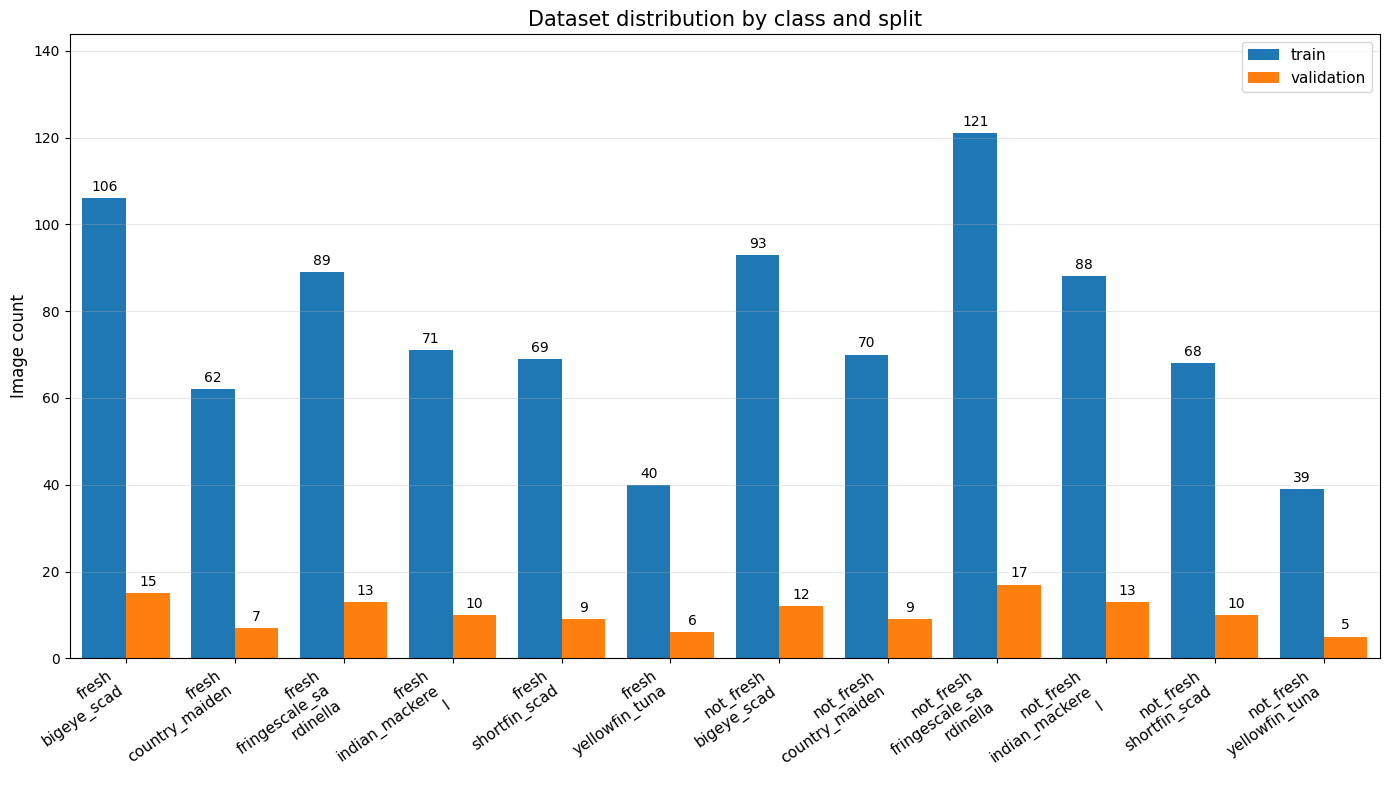

Loaded duplicates from: C:\aziztebbeng\2025-CP_Fishfresh\model\models\duplicates.csv
CSV removed total: 52


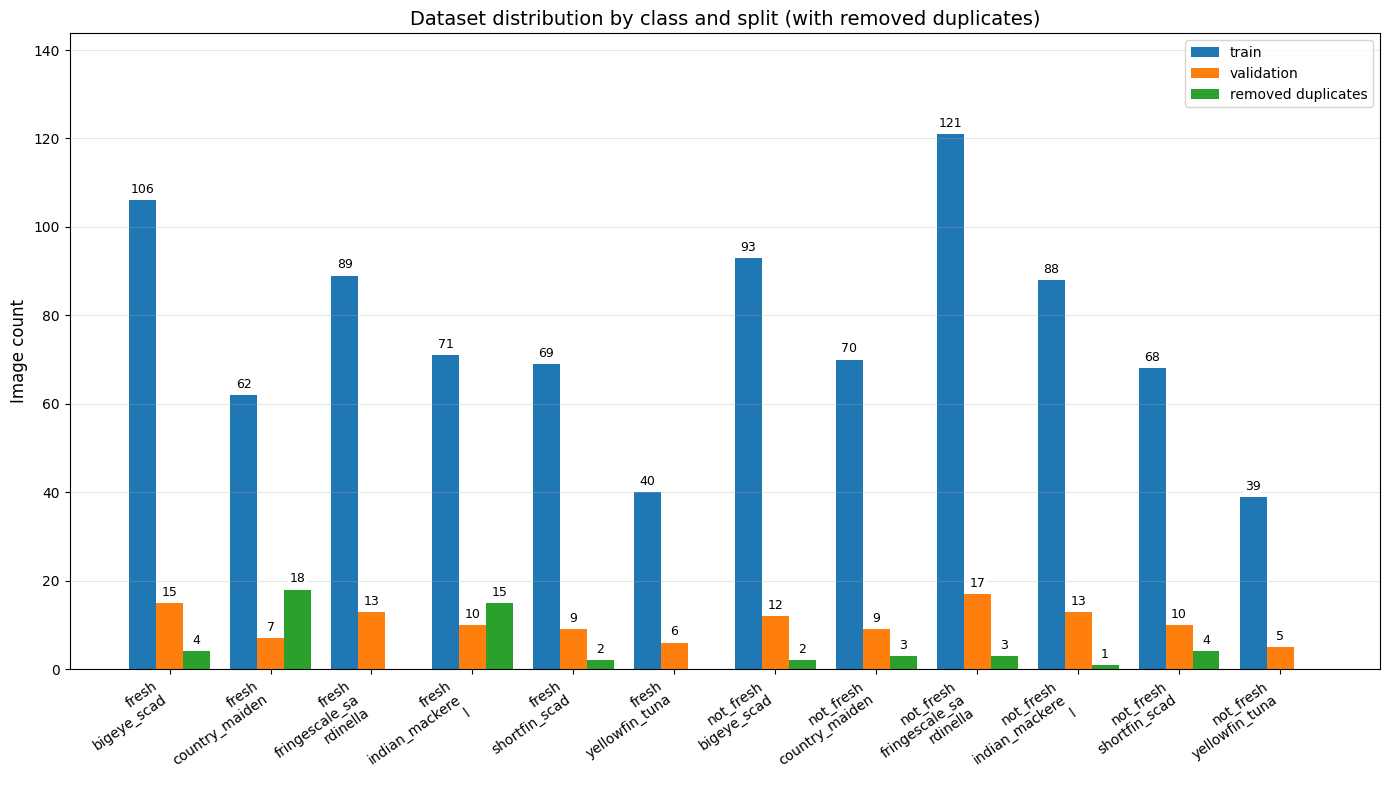

Removed shown in chart (sum): 52
First 6 class/removed: [('fresh__bigeye_scad', np.int64(4)), ('fresh__country_maiden', np.int64(18)), ('fresh__fringescale_sardinella', np.int64(0)), ('fresh__indian_mackerel', np.int64(15)), ('fresh__shortfin_scad', np.int64(2)), ('fresh__yellowfin_tuna', np.int64(0))]


In [6]:
# === CLEANED DATASET DISTRIBUTION CHARTS (readable labels + exact numbers) ===
# Works with: datasets/{train,validation,testing}/{fresh|not_fresh}/{species}/*.jpg
from pathlib import Path
import os, sys, subprocess, textwrap

# --- CONFIG ---
ROOT   = Path("datasets")                   # base dataset folder
SPLITS = ["train","validation","testing"]   # split names present on disk
SAVE_DIR = Path("models") if Path("models").exists() else Path("model/models")

# --- ensure deps ---
try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas","numpy"])
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

# High-DPI for crisp text
plt.gcf().set_dpi(150)

# --- helpers ---
def wrap_class_label(c, width=14):
    """Turn 'fresh__indian_mackerel' -> 'fresh\nindian_mackerel' and wrap long species."""
    parts = c.split("__", 1)
    if len(parts) == 2:
        fresh, species = parts
        species_wrapped = "\n".join(textwrap.wrap(species, width))
        return f"{fresh}\n{species_wrapped}"
    return "\n".join(textwrap.wrap(c, width))

def add_labels_on_bars(bars, values, fontsize=10, pad=3):
    """Add integer labels on top of vertical bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        h = rect.get_height()
        x = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (x, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

def add_labels_on_barh(bars, values, fontsize=10, pad=3):
    """Add integer labels at the end of horizontal bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        w = rect.get_width()
        y = rect.get_y() + rect.get_height()/2
        plt.annotate(
            f"{int(v)}",
            (w, y),
            xytext=(pad, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

# --- count images per class & split ---
EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}
rows = []
for split in SPLITS:
    base = ROOT / split
    if not base.exists():
        print(f"[skip] missing split: {base}")
        continue
    for freshness in ["fresh","not_fresh"]:
        fdir = base / freshness
        if not fdir.exists():
            continue
        for species_dir in sorted([p for p in fdir.iterdir() if p.is_dir()]):
            n = sum(1 for p in species_dir.rglob("*") if p.suffix.lower() in EXTS)
            rows.append({"class": f"{freshness}__{species_dir.name}", "split": split, "count": n})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No images found. Check ROOT/SPLITS and your folder structure.")

wide = (
    df.pivot_table(index="class", columns="split", values="count", aggfunc="sum")
      .fillna(0).astype(int)
      .sort_index()
)

SAVE_DIR.mkdir(parents=True, exist_ok=True)
(wide.to_csv(SAVE_DIR/"dataset_counts.csv"))
print("Saved counts ->", (SAVE_DIR/"dataset_counts.csv").resolve())

# --- optional: duplicates removed (if report exists) ---
dup_csv = SAVE_DIR/"duplicates.csv"
dup_counts = None
if dup_csv.exists():
    try:
        ddf = pd.read_csv(dup_csv)
        if "group" in ddf.columns:
            # normalize: convert backslashes, then replace "/" with "__"
            ddf["class_norm"] = (
                ddf["group"].astype(str)
                   .str.replace("\\\\", "/", regex=True)
                   .str.replace("/", "__", regex=False)
            )
            dup_counts = (
                ddf.groupby("class_norm").size()
                   .rename("removed")
                   .to_frame()
            )
            dup_counts.index.name = "class"
            print("Loaded duplicate removals from:", dup_csv.resolve())
            print("Total removed duplicates:", int(dup_counts["removed"].sum()))
        else:
            print("duplicates.csv missing 'group' column; no overlay will be shown.")
    except Exception as e:
        print("Could not read duplicates.csv:", e)
# -------------------------------
# Chart 1: Grouped bars per split
# -------------------------------
classes = wide.index.tolist()
labels_wrapped = [wrap_class_label(c, width=14) for c in classes]
present_splits = [s for s in SPLITS if s in wide.columns]
n_classes = len(classes)
n_splits  = max(1, len(present_splits))
x = np.arange(n_classes)
bar_w = 0.8 / n_splits

fig_w = max(14, n_classes * 1.0)
fig_h = 8
plt.figure(figsize=(fig_w, fig_h))
containers = []

for k, split in enumerate(present_splits):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    bars = plt.bar(xs, wide[split].values, width=bar_w, label=split)
    containers.append((bars, wide[split].values))

# labels on bars
for bars, vals in containers:
    add_labels_on_bars(bars, vals, fontsize=10, pad=3)

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=11)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split", fontsize=15)
plt.legend(fontsize=11)
plt.grid(axis="y", alpha=0.3)
plt.margins(x=0.01)

# y-axis headroom so labels don’t clip
ymax = max(wide[split].max() for split in present_splits) if present_splits else 0
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# -------------------------------------------
# Chart 2 (FIXED): grouped bars + a 3rd "removed duplicates" bar
# - picks the correct duplicates.csv
# - unions classes so removed-only classes still appear
# -------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import time

def _pick_dup_csv():
    cands = [
        Path("models/duplicates.csv"),
        Path("model/models/duplicates.csv"),
        Path("model/model/models/duplicates.csv"),
    ]
    cands = [p for p in cands if p.exists()]
    if not cands:
        return None
    # choose the most recently modified
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

# 1) Rebuild 'wide' if needed (assumes you already have it from Chart 1)
#    wide: index=class ("fresh__species"), columns=[train, validation, testing], values=int

# 2) Load duplicates.csv (most recent in common locations)
dup_csv = _pick_dup_csv()
dup_counts = None
if dup_csv is not None:
    ddf = pd.read_csv(dup_csv)
    def _norm_group(g: str) -> str:
        s = str(g).replace("\\", "/").replace("__", "/")
        parts = [p for p in s.split("/") if p]
        if len(parts) >= 2:
            return f"{parts[-2]}__{parts[-1]}"
        return s.replace("/", "__")
    if "group" in ddf.columns:
        ddf["class_norm"] = ddf["group"].map(_norm_group)
        dup_counts = (
            ddf.groupby("class_norm").size().rename("removed").to_frame()
        )
        dup_counts.index.name = "class"
        print("Loaded duplicates from:", dup_csv.resolve())
        print("CSV removed total:", int(dup_counts["removed"].sum()))
    else:
        print("duplicates.csv missing 'group' column; no removed bar will be shown.")
else:
    print("No duplicates.csv found in expected locations.")

# 3) Build the x-axis class list as a UNION (bars also for classes with zero left)
classes_all = set(wide.index.tolist())
if dup_counts is not None:
    classes_all |= set(dup_counts.index.tolist())
classes = sorted(classes_all)

# reindex 'wide' to include empty classes as zeros
present_splits = [s for s in SPLITS if s in wide.columns]
wide = wide.reindex(classes).fillna(0).astype(int)

# vector aligned with classes for removed
dup_vec = np.zeros(len(classes), dtype=int)
if dup_counts is not None:
    dup_vec = dup_counts.reindex(classes).fillna(0)["removed"].astype(int).values

# 4) Draw grouped bars: train/validation/[…]/removed
x = np.arange(len(classes))
bar_names = present_splits + ["removed"]
n_bars = len(bar_names)
bar_w = 0.8 / n_bars

plt.figure(figsize=(max(14, len(classes) * 1.0), 8))
bar_containers = []

for k, name in enumerate(bar_names):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    if name == "removed":
        vals = dup_vec
        bars = plt.bar(xs, vals, width=bar_w, label="removed duplicates")
    else:
        vals = wide[name].values if name in wide.columns else np.zeros(len(classes), dtype=int)
        label_name = "test" if name == "testing" else name
        bars = plt.bar(xs, vals, width=bar_w, label=label_name)
    bar_containers.append((bars, vals))

def _add_labels(bars, vals, fontsize=9, pad=3):
    for rect, v in zip(bars, vals):
        h = rect.get_height()
        if h <= 0: 
            continue
        cx = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (cx, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
        )

# annotate every bar
for bars, vals in bar_containers:
    _add_labels(bars, vals)

# x labels
def wrap_label(c, width=14):
    a = c.split("__", 1)
    if len(a) == 2:
        return a[0] + "\n" + "\n".join(pd.Series([a[1]]).str.wrap(width).iloc[0].split("\n"))
    return c
labels_wrapped = [wrap_label(c, 14) for c in classes]

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=10)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split (with removed duplicates)", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=10)

# headroom
ymax = 0
for _, vals in bar_containers:
    if len(vals):
        ymax = max(ymax, int(np.max(vals)))
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# 5) Sanity checks
print("Removed shown in chart (sum):", int(dup_vec.sum()))
print("First 6 class/removed:", list(zip(classes[:6], dup_vec[:6])))



## 6) (Datasets Splitting) Flatten dataset to ImageFolder layout

In [7]:
# 3) Flatten dataset to ImageFolder (robust paths)
from pathlib import Path
import shutil, json

# ---- Auto-detect where the 'model/' folder is relative to this notebook ----
if Path('datasets/train').exists():            # prefer root
    MODEL_DIR = Path('.')
elif Path('model/datasets/train').exists():    # fallback
    MODEL_DIR = Path('model')
else:
    # last resort: search upwards
    cand = [p.parent for p in Path.cwd().rglob('datasets/train')]
    if cand:
        MODEL_DIR = cand[0]
    else:
        raise SystemExit("Couldn't find 'datasets/train'. Set MODEL_DIR manually.")

print("MODEL_DIR ->", MODEL_DIR.resolve())

SRC = MODEL_DIR / 'datasets'                    # expects train/, validation/, (test/)
DST = MODEL_DIR / 'pytorch_imagenet'            # will create train/, val/, test/
DST.mkdir(parents=True, exist_ok=True)

def flatten_split(split_name, out_name):
    src = SRC / split_name
    out = DST / out_name
    if not src.exists():
        print(f"[skip] {src} not found")
        return False
    out.mkdir(parents=True, exist_ok=True)
    copied = 0
    for freshness in ['fresh', 'not_fresh']:
        base = src / freshness
        if not base.exists():
            print(f"[warn] missing {base}")
            continue
        for sp_dir in base.iterdir():
            if not sp_dir.is_dir(): 
                continue
            cls = f"{freshness}__{sp_dir.name}"
            out_cls = out / cls
            out_cls.mkdir(parents=True, exist_ok=True)
            for img in sp_dir.rglob('*'):
                if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}:
                    shutil.copy2(img, out_cls / img.name)
                    copied += 1
    print(f"[done] {split_name} -> {out}  (copied {copied} files)")
    return copied > 0

ok_train = flatten_split('train', 'train')
ok_val   = flatten_split('validation', 'val')
ok_test  = flatten_split('test', 'test')

if not ok_train:
    raise SystemExit("No training images were copied. Check your source layout: "
                     "model/datasets/train/{fresh,not_fresh}/{species}/*.jpg")

# Build structured class list (Freshness + Species)
train_dir = DST / 'train'
all_classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
NUM_CLASSES = len(all_classes)

# Extract species from folder names like 'fresh__indian_mackerel'
species_classes = sorted(set(c.split('__')[1] for c in all_classes if '__' in c))
freshness_classes = ["Fresh", "Not Fresh"]

# Make sure models directory exists
(MODEL_DIR/'models').mkdir(parents=True, exist_ok=True)

# Create a structured JSON format
structured_classes = {
    "freshness_classes": freshness_classes,
    "species_classes": species_classes
}

# Save the structured version
classes_path = MODEL_DIR / 'models' / 'classes.json'
classes_path.write_text(json.dumps(structured_classes, indent=2))

# Optional: also save the flat list (if you still want it)
(MODEL_DIR/'models'/'classes_flat.json').write_text(json.dumps(all_classes, indent=2))

print(f"✅ Wrote structured classes.json to {classes_path.resolve()}")
print(f"Total Classes: {NUM_CLASSES}")
print("Species:", species_classes)


MODEL_DIR -> C:\aziztebbeng\2025-CP_Fishfresh\model
[done] train -> pytorch_imagenet\train  (copied 916 files)
[done] validation -> pytorch_imagenet\val  (copied 126 files)
[done] test -> pytorch_imagenet\test  (copied 248 files)
✅ Wrote structured classes.json to C:\aziztebbeng\2025-CP_Fishfresh\model\models\classes.json
Total Classes: 12
Species: ['bigeye_scad', 'country_maiden', 'fringescale_sardinella', 'indian_mackerel', 'shortfin_scad', 'yellowfin_tuna']


## 7) (Augmentation) Dataloaders & transforms with downsampling the training set

In [8]:
# === DATALOADERS with class-balanced downsampling (to smallest class or a target cap) ===
from pathlib import Path
from collections import Counter, defaultdict
import random
import torch
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms

# ---- defaults if not already defined above ----
INPUT_SIZE   = int(globals().get('INPUT_SIZE', 224))
BATCH        = int(globals().get('BATCH', 16))
NUM_WORKERS  = int(globals().get('NUM_WORKERS', 0))  # Windows CPU: keep 0
PIN_MEMORY   = bool(globals().get('PIN_MEMORY', torch.cuda.is_available()))
SEED         = int(globals().get('SEED', 123))

# If you want to force an upper cap (e.g., 120 per class), set to an int.
# If None, it will balance to the smallest class automatically.
TARGET_PER_CLASS = 200  # change here if you want

random.seed(SEED)
torch.manual_seed(SEED)

# ---- locate flattened dataset root ----
if Path('model/pytorch_imagenet/train').exists():
    DST = Path('model/pytorch_imagenet')
elif Path('pytorch_imagenet/train').exists():
    DST = Path('pytorch_imagenet')
else:
    raise SystemExit("Couldn't find the flattened dataset. Run the flatten step first "
                     "(it creates model/pytorch_imagenet/{train,val}).")

VAL_DIR = DST/'val'
if not VAL_DIR.exists():
    alt = DST/'validation'
    if alt.exists():
        VAL_DIR = alt
    else:
        raise SystemExit(f"Missing validation split at {DST/'val'} (or {alt}).")

# ---- transforms (mild, species-friendly) ----
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3), value='random')
])
val_tfms = transforms.Compose([
    transforms.Resize(int(INPUT_SIZE*1.15)),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ---- build base datasets ----
train_base = datasets.ImageFolder(DST/'train', transform=train_tfms)
val_ds     = datasets.ImageFolder(VAL_DIR,     transform=val_tfms)

# Define CLASSES if not already set
if 'CLASSES' not in globals():
    CLASSES = train_base.classes

# ---------- helpers ----------
def labels_from_dataset(ds):
    if hasattr(ds, "targets"):
        return list(ds.targets)
    elif hasattr(ds, "samples"):
        return [y for _, y in ds.samples]
    raise AttributeError("Expected torchvision ImageFolder-like dataset.")

def count_by_class(ds, indices=None):
    if indices is None:
        labels = labels_from_dataset(ds)
    else:
        if hasattr(ds, "targets"):
            labels = [ds.targets[i] for i in indices]
        else:
            labels = [ds.samples[i][1] for i in indices]
    return Counter(labels)

# ---- show counts BEFORE ----
before_counts = count_by_class(train_base)
print("Before (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {before_counts.get(i,0)}")
print(f"Total before: {sum(before_counts.values())}\n")

# ---- balanced index selection ----
# group indices by class
idxs_by_class = defaultdict(list)
for idx, (_, y) in enumerate(train_base.samples):
    idxs_by_class[y].append(idx)

min_class_size = min(len(v) for v in idxs_by_class.values())
cap = min_class_size if TARGET_PER_CLASS is None else min(TARGET_PER_CLASS, max(len(v) for v in idxs_by_class.values()))

balanced_indices = []
for c, idxs in idxs_by_class.items():
    k = min(len(idxs), cap)  # don’t oversample here; strictly downsample to cap
    balanced_indices.extend(random.sample(idxs, k))

# create balanced Subset for training
train_ds = Subset(train_base, balanced_indices)

# ---- show counts AFTER ----
after_counts = count_by_class(train_base, balanced_indices)
print("After (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {after_counts.get(i,0)}")
print(f"Total after: {sum(after_counts.values())}\n")

# ---- dataloaders ----
loaders = {
    'train': DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
    'val':   DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
}

print("Using dataset root:", DST.resolve())
print("Train classes:", len(CLASSES),
      "  Train batches:", len(loaders['train']),
      "  Val batches:", len(loaders['val']))
print("INPUT_SIZE:", INPUT_SIZE, " BATCH:", BATCH, " NUM_WORKERS:", NUM_WORKERS, " PIN_MEMORY:", PIN_MEMORY)

# OPTIONAL: if you prefer to keep all data (no downsampling) but balance by sampling probability,
# comment out the Subset above and use a WeightedRandomSampler like this:
# counts = torch.tensor([before_counts[i] for i in range(len(CLASSES))], dtype=torch.float)
# class_w = 1.0 / counts
# sample_w = class_w[labels_from_dataset(train_base)]
# sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
# loaders['train'] = DataLoader(train_base, batch_size=BATCH, sampler=sampler,
#                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)


Before (per class):
  fresh__bigeye_scad                  -> 106
  fresh__country_maiden               -> 62
  fresh__fringescale_sardinella       -> 117
  fresh__indian_mackerel              -> 92
  fresh__shortfin_scad                -> 87
  fresh__yellowfin_tuna               -> 40
  not_fresh__bigeye_scad              -> 121
  not_fresh__country_maiden           -> 70
  not_fresh__fringescale_sardinella   -> 158
  not_fresh__indian_mackerel          -> 115
  not_fresh__shortfin_scad            -> 88
  not_fresh__yellowfin_tuna           -> 39
Total before: 1095

After (per class):
  fresh__bigeye_scad                  -> 106
  fresh__country_maiden               -> 62
  fresh__fringescale_sardinella       -> 117
  fresh__indian_mackerel              -> 92
  fresh__shortfin_scad                -> 87
  fresh__yellowfin_tuna               -> 40
  not_fresh__bigeye_scad              -> 121
  not_fresh__country_maiden           -> 70
  not_fresh__fringescale_sardinella   -> 158
  not_fr

## 7.1 Weighted CrossEntropyloss for imbalance datasets

In [10]:
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

# get labels from your train_ds
if hasattr(train_ds, "targets"):
    labels = np.array(train_ds.targets)
else:
    labels = np.array([train_ds.dataset.targets[i] for i in train_ds.indices])

counts = Counter(labels)
n_samples = len(labels)
n_classes = len(CLASSES)

# balanced class weights
raw = np.array([n_samples / (n_classes * counts[i]) for i in range(n_classes)], dtype=np.float32)
raw = raw / raw.mean()  # normalize so mean ~1

weights = torch.tensor(raw, dtype=torch.float32)

# ⬇️ ADD THIS PRINT HERE
print("\n=== Class Counts & Weights ===")
for i, cls_name in enumerate(CLASSES):
    print(f"{i:2d}  {cls_name:30s}  count={counts[i]:3d}  weight={raw[i]:.3f}")
print()

# create final loss
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss(weight=weights.to(device))



=== Class Counts & Weights ===
 0  fresh__bigeye_scad              count=106  weight=0.725
 1  fresh__country_maiden           count= 62  weight=1.240
 2  fresh__fringescale_sardinella   count=117  weight=0.657
 3  fresh__indian_mackerel          count= 92  weight=0.836
 4  fresh__shortfin_scad            count= 87  weight=0.884
 5  fresh__yellowfin_tuna           count= 40  weight=1.922
 6  not_fresh__bigeye_scad          count=121  weight=0.636
 7  not_fresh__country_maiden       count= 70  weight=1.099
 8  not_fresh__fringescale_sardinella  count=158  weight=0.487
 9  not_fresh__indian_mackerel      count=115  weight=0.669
10  not_fresh__shortfin_scad        count= 88  weight=0.874
11  not_fresh__yellowfin_tuna       count= 39  weight=1.972



## 8) Build model from the selected GitHub repo

In [11]:
# === BUILD MobileNetV2 (official torchvision) ===
import torch, torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Determine class count from globals or datasets
if 'NUM_CLASSES' in globals():
    NUM_CLASSES = int(NUM_CLASSES)
elif 'CLASSES' in globals():
    NUM_CLASSES = len(CLASSES)
elif 'data' in globals() and 'train' in data:
    NUM_CLASSES = len(data['train'].classes)
else:
    raise SystemExit("Can't determine NUM_CLASSES. Run dataloaders first so CLASSES/data exist.")

# Load official ImageNet weights
weights = MobileNet_V2_Weights.IMAGENET1K_V1

# Build model and replace classifier
base = mobilenet_v2(weights=weights)
in_feats = base.classifier[1].in_features
base.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_feats, NUM_CLASSES, bias=True)
)
model = base.to(device)

print(f"Built official torchvision MobileNetV2 -> num_classes={NUM_CLASSES}")
with torch.no_grad():
    _ = model(torch.randn(1,3,224,224, device=device))
print('Sanity forward OK on', device)


Built official torchvision MobileNetV2 -> num_classes=12
Sanity forward OK on cpu


In [12]:
# Install tqdm from inside the notebook (Windows-safe temp paths)
import sys, subprocess, os
from pathlib import Path
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "tqdm"])

from tqdm.auto import tqdm
print("tqdm ready ✅")


tqdm ready ✅


## 8.1) MODEL CONFIRMATION

In [13]:
# === MODEL SOURCE CONFIRMATION — MobileNetV2 (torchvision, robust) ===
import torch
from torchvision import models
from torchvision.transforms import Normalize

print("PyTorch version:", torch.__version__)
print("Model source:", models.mobilenet.__name__)
print("Model name:", "MobileNetV2")

# Load a temporary pretrained model (for param count + sanity)
weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
m_pretrained = models.mobilenet_v2(weights=weights)

# --- helper to get mean/std even if meta is missing ---
def extract_mean_std(weights_enum):
    # 1) Try weights.meta
    mean = std = None
    source = None
    try:
        meta = weights_enum.meta
        mean = meta.get("mean", None)
        std  = meta.get("std", None)
        if mean is not None and std is not None:
            return list(mean), list(std), "weights.meta"
    except Exception:
        pass
    # 2) Walk transforms and find Normalize
    try:
        tfm = weights_enum.transforms()
        stack = [tfm]
        seen = set()
        while stack:
            t = stack.pop()
            if id(t) in seen: 
                continue
            seen.add(id(t))
            if isinstance(t, Normalize):
                return list(t.mean), list(t.std), "weights.transforms()"
            # Compose / RandomApply / etc. usually store children in `.transforms`
            if hasattr(t, "transforms") and isinstance(getattr(t, "transforms"), (list, tuple)):
                stack.extend(t.transforms)
            # torchvision ≥0.15 sometimes nests under .transform or .aug
            for attr in ("transform", "aug"):
                if hasattr(t, attr):
                    stack.append(getattr(t, attr))
    except Exception:
        pass
    # 3) Fallback to ImageNet defaults
    return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], "fallback(defaults)"

mean, std, src = extract_mean_std(weights)

# Try to pull other metadata safely
def safe(meta_key, default="N/A"):
    try:
        v = weights.meta.get(meta_key, None)
        return v if v is not None else default
    except Exception:
        return default

print("\nPretrained configuration metadata:")
print("• Weights enum:", weights)
print("• Weights URL:", safe("url", "None"))
print("• Categories:", len(safe("categories", [])), "(ImageNet classes)")
print("• Input size expected:", safe("input_size", "(3, 224, 224)"))
print("• Mean:", mean, f"(source: {src})")
print("• Std:", std,   f"(source: {src})")
print("• Model architecture:", m_pretrained.__class__.__name__)
print("• Parameter count:", f"{sum(p.numel() for p in m_pretrained.parameters()):,}")

# Compare to your fine-tuned model if it's already defined
if 'model' in globals():
    p1 = sum(p.numel() for p in m_pretrained.parameters())
    p2 = sum(p.numel() for p in model.parameters())
    print(f"\nParameter difference (pretrained vs fine-tuned): {abs(p1 - p2):,}")
    print(f"✅ Using pretrained MobileNetV2 backbone replaced to output "
          f"{getattr(getattr(model, 'classifier', None), '__getitem__', lambda i: None)(-1).out_features if hasattr(getattr(model, 'classifier', None), '__getitem__') else getattr(getattr(model, 'classifier', None), 'out_features', '?')} classes.")
else:
    print("\n⚠️ Fine-tuned model not yet loaded — showing pretrained metadata only.")


PyTorch version: 2.8.0+cpu
Model source: torchvision.models.mobilenet
Model name: MobileNetV2

Pretrained configuration metadata:
• Weights enum: MobileNet_V2_Weights.IMAGENET1K_V1
• Weights URL: None
• Categories: 1000 (ImageNet classes)
• Input size expected: (3, 224, 224)
• Mean: [0.485, 0.456, 0.406] (source: fallback(defaults))
• Std: [0.229, 0.224, 0.225] (source: fallback(defaults))
• Model architecture: MobileNetV2
• Parameter count: 3,504,872

Parameter difference (pretrained vs fine-tuned): 1,265,628
✅ Using pretrained MobileNetV2 backbone replaced to output 12 classes.


## 9) Train with SGD + Cosine LR + AMP

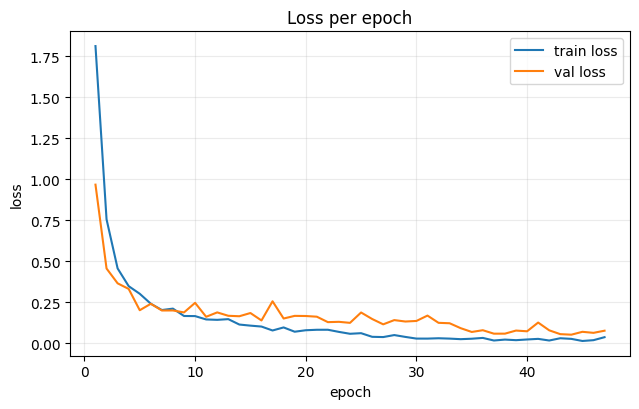

Epoch 47/90 train loss 0.0371 acc 0.9918 | val loss 0.0767 acc 0.9707 (best 0.9902) LR 0.000470


  0%|          | 0/69 [00:00<?, ?it/s]

In [ ]:
# === TRAIN + LIVE LOSS PLOT (per-epoch) — Single-head + AMP (MobileNetV2) ===

import torch, torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from pathlib import Path

# Reuse your globals if already set; otherwise fall back to sane defaults
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = int(globals().get('EPOCHS', 90))
LR = float(globals().get('LR', 0.001))  # single LR like your other cells
WEIGHT_DECAY = float(globals().get('WEIGHT_DECAY', 1e-4))  # align with other cells
MODEL_DIR = Path('model') if Path('model').exists() else Path('.')
OUT_DIR = MODEL_DIR / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPO = str(globals().get('REPO', 'torchvision')).lower()

# Expect these to exist
model = globals().get('model', model).to(device)  # your MobileNetV2 (torchvision)
loaders = globals().get('loaders', loaders)       # loaders['train'], loaders['val']
criterion = globals().get('criterion', nn.CrossEntropyLoss())
optimizer = globals().get(
    'optimizer',
    SGD(model.parameters(), lr=LR, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY)
)

# ✅ match the others: cosine with eta_min
scheduler = globals().get(
    'scheduler',
    CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
)

# ✅ AMP
scaler = GradScaler(enabled=(device.type == 'cuda'))
best_acc = 0.0
ckpt_path = OUT_DIR / 'mbv2_torchvision_best.pth'
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0

    for x, y in tqdm(dl, leave=False):
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            # 🔥 AMP forward/backward (same pattern as your effnet/resnet cells)
            with autocast(enabled=(device.type == 'cuda')):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with autocast(enabled=(device.type == 'cuda')):
                    out = model(x)
                    loss = criterion(out, y)

        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return loss_sum / max(1, total), correct / max(1, total)


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(loaders['train'], train=True)
    va_loss, va_acc = run_epoch(loaders['val'], train=False)
    scheduler.step()

    # record
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    # save best (same fields as your other cells)
    if va_acc >= best_acc:
        best_acc = va_acc
        torch.save({
            'model': model.state_dict(),
            'classes': globals().get('CLASSES', []),
            'epoch': epoch,
            'val_acc': best_acc
        }, ckpt_path)

    # ---- live plot: loss per epoch ----
    clear_output(wait=True)
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(6.5, 4.2))
    plt.plot(epochs, history["train_loss"], label='train loss')
    plt.plot(epochs, history["val_loss"], label='val loss')
    plt.title('Loss per epoch')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

    print(
        f"Epoch {epoch}/{EPOCHS} "
        f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f} "
        f"(best {best_acc:.4f}) "
        f"LR {optimizer.param_groups[0]['lr']:.6f}"
    )

# (optional) persist history
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(OUT_DIR / 'training_history.csv', index=False)
except Exception:
    pass

print("Best val acc:", best_acc, "\nSaved best checkpoint ->", ckpt_path)


#### 9.1 Validation After Training

In [12]:
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in loaders['val']:
        x = x.to(next(model.parameters()).device)
        preds = model(x).argmax(1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(y.tolist())

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))


                                   precision    recall  f1-score   support

               fresh__bigeye_scad      1.000     0.933     0.966        15
    fresh__fringescale_sardinella      1.000     1.000     1.000        13
           fresh__indian_mackerel      1.000     1.000     1.000         9
             fresh__mackerel_scad      1.000     0.900     0.947        10
           not_fresh__bigeye_scad      0.923     0.923     0.923        13
not_fresh__fringescale_sardinella      1.000     1.000     1.000        17
       not_fresh__indian_mackerel      1.000     1.000     1.000        13
         not_fresh__mackerel_scad      0.833     1.000     0.909        10

                         accuracy                          0.970       100
                        macro avg      0.970     0.970     0.968       100
                     weighted avg      0.973     0.970     0.970       100



## 10) Graph Accuracy Plot: Training vs Validation 

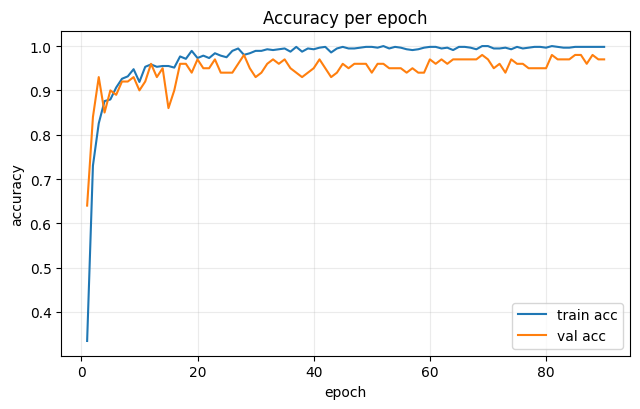

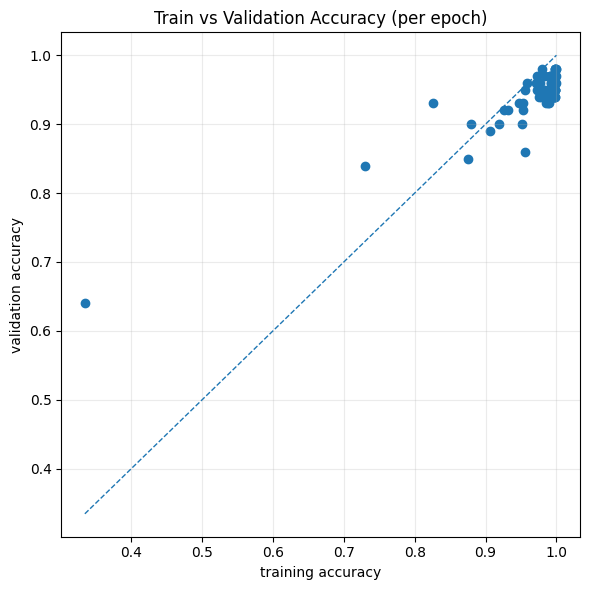

Avg gen gap (train - val): 0.0266   |   Max gap: 0.0950


In [13]:
# === ACCURACY PLOTS: line (per epoch) + XY (train vs val) ===

import os, sys, subprocess
from pathlib import Path

# make sure matplotlib/pandas are available (installs once if missing)
try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas"])
    import matplotlib.pyplot as plt
    import pandas as pd

OUT_DIR = Path("model/models") if Path("model").exists() else Path("models")

# 1) get history (prefer in-memory; else load CSV saved by training cell)
hist = None
if "history" in globals() and isinstance(history, dict) and history.get("train_acc"):
    hist = history
elif (OUT_DIR/"training_history.csv").exists():
    df = pd.read_csv(OUT_DIR/"training_history.csv")
    cols = [c for c in ["train_acc","val_acc","train_loss","val_loss"] if c in df.columns]
    hist = {k: df[k].tolist() for k in cols}

if not hist or "train_acc" not in hist or "val_acc" not in hist:
    raise SystemExit("No accuracy history found. Run training (or save training_history.csv) first.")

epochs = range(1, len(hist["train_acc"])+1)

# 2) line chart: accuracy vs epoch
plt.figure(figsize=(6.5,4.2))
plt.plot(epochs, hist["train_acc"], label="train acc")
plt.plot(epochs, hist["val_acc"],   label="val acc")
plt.title("Accuracy per epoch")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# 3) XY scatter: train acc (X) vs val acc (Y) + y=x line
import numpy as np
ta = np.array(hist["train_acc"], dtype=float)
va = np.array(hist["val_acc"],   dtype=float)

plt.figure(figsize=(6.0,6.0))
plt.scatter(ta, va)
mn = float(min(ta.min(), va.min()))
mx = float(max(ta.max(), va.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)  # y = x reference
plt.xlabel("training accuracy")
plt.ylabel("validation accuracy")
plt.title("Train vs Validation Accuracy (per epoch)")
plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# (optional) quick text summary
gap = (ta - va)
print(f"Avg gen gap (train - val): {gap.mean():.4f}   |   Max gap: {gap.max():.4f}")


## 11) Test set evaluation

In [14]:
from torch.utils.data import DataLoader
from torchvision import datasets
if (DST/'test').exists():
    test_ds = datasets.ImageFolder(DST/'test', transform=val_tfms)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred==y).sum().item(); total += x.size(0)
    print('Test accuracy:', correct/max(1,total))
else:
    print('No test split found — skipping.')

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test accuracy: 0.9329896907216495


## 12) Export TorchScript (.pt) and ONNX (.onnx)

In [15]:
model.eval()
dummy = torch.randn(1,3,INPUT_SIZE,INPUT_SIZE).to(device)

# TorchScript
ts = torch.jit.trace(model, dummy)
ts_path = MODEL_DIR/'models'/'mobilenetv2_torchvision.pt'
ts.save(str(ts_path))
print('Saved TorchScript ->', ts_path.resolve())


Saved TorchScript -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\mobilenetv2_torchvision.pt


## 13) EXPORTING TO ONNX FROM TOURCHSCRIPT .PT WITH A HUMAN READABLE TIMESTAMP

In [16]:
# --- ONNX export (legacy exporter) with timestamped filename (torchvision) ---
import torch
from pathlib import Path
from datetime import datetime

model.eval().cpu()
dummy = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)  # CPU dummy

MODEL_DIR = Path('model') if Path('model').exists() else Path('.')
(MODEL_DIR/'models').mkdir(parents=True, exist_ok=True)

dt = datetime.now()
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sept",10:"Oct",11:"Nov",12:"Dec"}
hour12 = dt.hour % 12 or 12
ampm = "am" if dt.hour < 12 else "pm"
stamp = f"{month_map[dt.month]}_{dt.day}_{hour12}-{dt.minute:02d}_{ampm}"

onnx_path = MODEL_DIR / "models" / f"mobilenetv2_torchvision_{stamp}.onnx"

torch.onnx.export(
    model, dummy, str(onnx_path),
    input_names=['input'], output_names=['logits'],
    opset_version=13,
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    dynamo=False,
)
print("Saved ONNX ->", onnx_path.resolve())


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19376\3823555497.py:20: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Saved ONNX -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\mobilenetv2_torchvision_Nov_2_3-38_am.onnx


---
### Notes & References
- **d-li14** repo: README usage and imagenet training flags (cosine LR, 0.05 LR, 4e-5 WD, 224px) — we mirror those defaults here.
- **tonylins** repo: canonical MobileNetV2 module; we import it directly and set `num_classes`.
- Normalization uses ImageNet mean/std; resize/crop = 224.
- You can raise `EPOCHS`, use label smoothing, or RandAugment to push accuracy if needed.


In [ ]:
# Run this IN THE NOTEBOOK so it installs into the current kernel
import sys, subprocess
print("Kernel python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U",
                       "onnx>=1.15,<1.18", "onnxscript>=0.1.0,<0.2.0"])